

**Algorithm 4.1: k-NN**

**Inputs:** Training dataset (T), distance metric (d), Test instance (t), the number of nearest neighbors (k)
**Output:** Predicted class or category

**Prediction:** For test instance (t),

1. For each instance (i) in (T), compute the distance between the test instance (t) and every other instance (i) in the training dataset using a distance metric (Euclidean distance).

   * **Continuous attributes –** Euclidean distance between two points in the plane with coordinates ((x_1, y_1)) and ((x_2, y_2)) is given as:
     [
     \text{dist}((x_1, y_1), (x_2, y_2)) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
     ]

   * **Categorical attributes (Binary) –** Hamming Distance: If the value of the two instances is same, the distance (d = 0), otherwise (d = 1).

2. Sort the distances in ascending order and select the first (k) nearest training data instances to the test instance.

3. Predict the class of the test instance by majority voting (if target attribute is discrete valued) or mean (if target attribute is continuous valued) of the (k) selected nearest instances.




In [2]:
import pandas as pd 
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap




In [3]:
data=load_iris()


In [4]:
dataset=pd.DataFrame(data=data.data ,columns=data.feature_names)
dataset['species_name']=data.target

In [5]:
dataset.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_name
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [6]:
dataset['species_name'] = dataset['species_name'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [7]:
x=dataset.drop('species_name',axis=1)
y=dataset['species_name']

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaled=StandardScaler()
x_scaled=scaled.fit_transform(x_train)
x_test_scaled=scaled.transform(x_test)

In [9]:
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_scaled,y_train)

KNeighborsClassifier()

In [10]:
y_predict=model.predict(x_test_scaled)

In [11]:
print(accuracy_score(y_test,y_predict))

1.0


In [12]:
new_sample =scaled.transform( np.array([[6.1, 3.0, 4.5, 1.5]]))


c:\Users\layap\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
new_prediction=model.predict(new_sample)

In [14]:
print(new_prediction)

['versicolor']


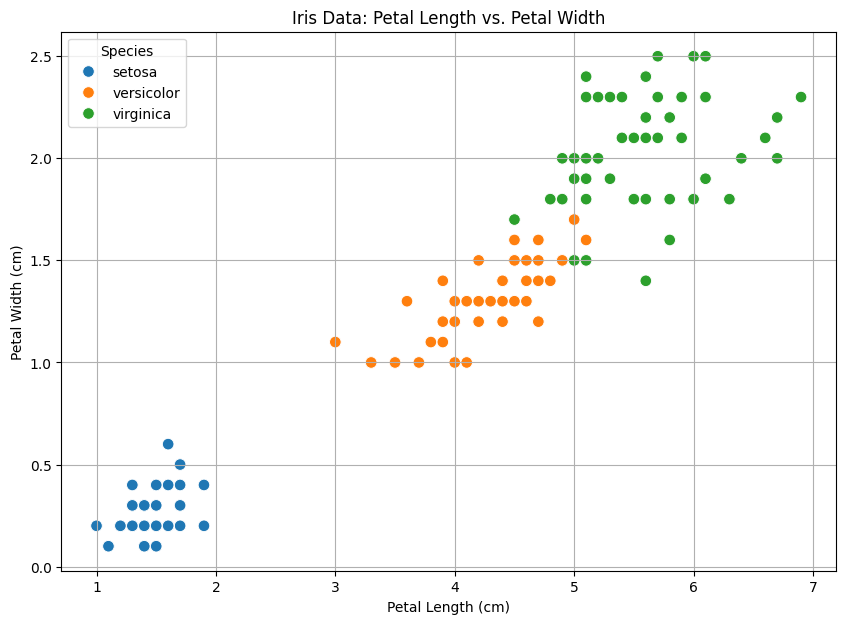

In [15]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species_name',
    data=dataset,
    s=70 
)

plt.title('Iris Data: Petal Length vs. Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.grid(True)
plt.show()

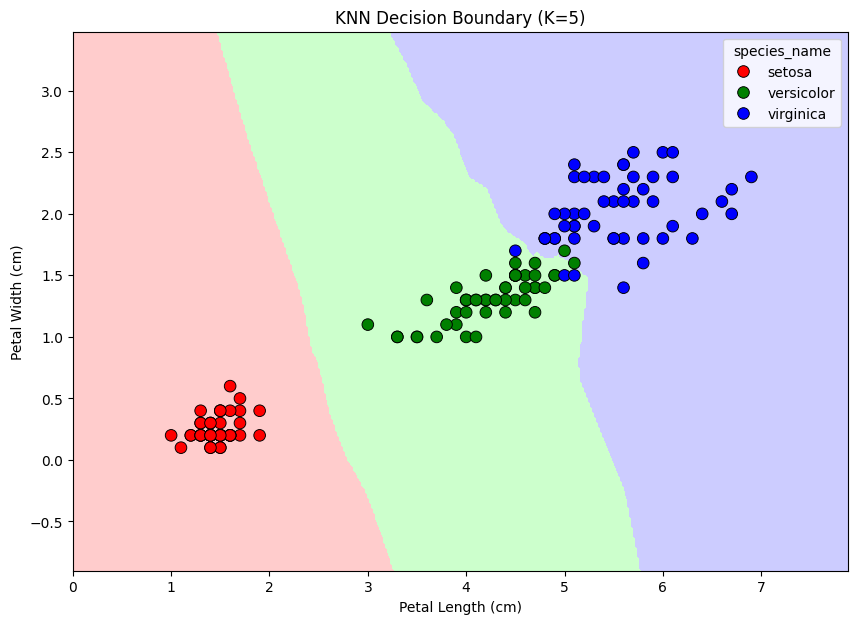

In [16]:

X_plot = data.data[:, 2:]
y_plot = data.target


model_2d = KNeighborsClassifier(n_neighbors=5)
model_2d.fit(X_plot, y_plot)


cmap_light = ListedColormap(['#FFCCCC', '#CCFFCC', '#CCCCFF'])

x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1


xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))


Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(10, 7))


plt.contourf(xx, yy, Z, cmap=cmap_light)


sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], hue=dataset['species_name'],
                palette=['red', 'green', 'blue'],
                alpha=1.0, edgecolor="black", s=70)

plt.title("KNN Decision Boundary (K=5)")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.show()